# 9. Временной граф: GNN/GAT для одномерного ряда

**Цель:** библиотека (commit `816f975`) добавила `graph_evt_agent.temporal` — способ обучать ту же GNN/GAT-машинерию, что и для многоканальных данных (ноутбук `n-d/09`), на **одномерных** записях. Узлами графа становятся не каналы, а перекрывающиеся временные окна; целевой узел — окно, содержащее момент события. `ProcessModelTrainer.train_1d` — тонкая обёртка над тем же `.train()`, тем же `split_episodes` (деление по целым записям) и теми же метриками (`RankingMetrics`, `summary_table`), что и в `n-d/09`; `GraphProcessModel.save`/`.load` — та же persistence-логика без pickle.

Этот ноутбук: (1) строит временной граф и обучает GNN/GAT на многих независимых одномерных записях; (2) переиспользует ту же обучающую/оценочную инфраструктуру, что и n-D путь; (3) явно показывает, как предсказанный узел превращается обратно в окно времени, и как согласовать `baseline_size` временного графа с `baseline_size` EVT-конфигурации, используемой в остальных `1-d`-ноутбуках.

## 0. Установка и совместимость

Функциональность требует commit `816f975` или новее (`requirements.txt`/`pyproject.toml` этого модуля уже обновлены). Если `TemporalGraphConfig` не импортируется — переустановите зависимость: `pip install --force-reinstall --no-deps "graph-evt-agent[progress] @ git+https://github.com/D2718281828nis/Graph-EVT-agent.git@816f97586f58d709fde3fb63d95d6c462351476a"`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from graph_evt_agent import (
    GraphLearningConfig,
    ProcessModelTrainer,
    TemporalGraphConfig,
    univariate_temporal_graph,
)
from graph_evt_agent.learning import GraphProcessModel
from graph_evt_agent.localization import heuristic_probabilities
from importlib.metadata import version
print("graph-evt-agent version:", version("graph-evt-agent"))

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/additive_fractal_series.csv").exists())

# evt_demo.data_generator is this project's own module (src-layout), not part
# of graph-evt-agent; make it importable the same way n-d/09 does.
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

DATA = ROOT / "data/generated/additive_fractal_series.csv"
SEED = 42
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
assert np.isfinite(x).all() and x.ndim == 1
true_onset = int(np.flatnonzero(event_mask)[0])
true_onset

graph-evt-agent version: 0.1.0


672

## 1. От времени к узлам графа

`univariate_temporal_graph(values, config)` нарезает ряд на перекрывающиеся окна (`window_size`, шаг `stride`), соединяет соседние окна в кольцо-цепочку глубины `neighborhood`, и для каждого окна считает те же пять признаков, что и `rank_sources` для каналов: пик, энергию, задержку пика внутри окна, степень узла и пик соседей. Масштаб (`location`/`scale`) оценивается по `baseline_size` первых отсчётов — тому же типу робастной MAD-оценки, что и в `EVTConfig`, но здесь это отдельный параметр `TemporalGraphConfig.baseline_size`, а не `EVTConfig.baseline_size`.

In [2]:
# baseline_size for the temporal graph must stay valid across every training
# recording below (see section 2): generate_additive_fractal_series() never
# places an onset before n_points // 4 = 375 samples, so 300 is a safe
# constant margin, not a per-recording oracle value like `1-d/03`'s
# `BASELINE_SIZE = event_start`. This is intentional and discussed in section 5.
TEMPORAL_CONFIG = TemporalGraphConfig(window_size=32, stride=8, neighborhood=1, baseline_size=300)

features, adjacency, starts = univariate_temporal_graph(x, TEMPORAL_CONFIG)
print(f"{len(starts)} windows covering samples {starts.min()}-{starts.max() + TEMPORAL_CONFIG.window_size}")
print("feature columns: peak, energy, latency, degree, neighbor")
pd.DataFrame(features, columns=["peak", "energy", "latency", "degree", "neighbor"]).describe()

188 windows covering samples 0-1528
feature columns: peak, energy, latency, degree, neighbor


,peak,energy,latency,degree,neighbor
count,188.000000,188.000000,188.000000,188.000000,188.000000
mean,1.610660,1.229311,15.643617,1.989362,1.610660
std,1.646811,3.470475,10.711861,0.102866,1.575312
min,0.531367,0.074610,0.000000,1.000000,0.531367
25%,1.003764,0.215421,5.000000,2.000000,1.036511
50%,1.206772,0.428125,15.500000,2.000000,1.224768
75%,1.562859,0.912735,26.000000,2.000000,1.554651
max,10.037593,24.911201,31.000000,2.000000,10.037593


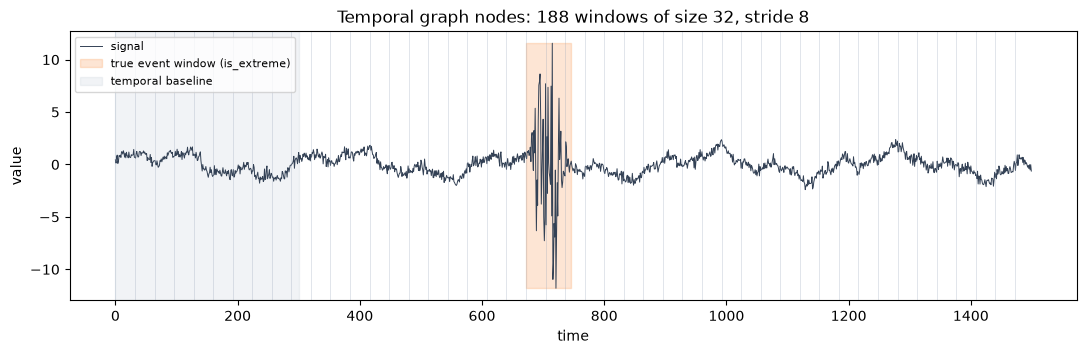

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df["timestamp"], x, color="#334155", linewidth=0.7, label="signal")
ax.fill_between(df["timestamp"], x.min(), x.max(), where=event_mask, color="#f97316", alpha=0.18,
                label="true event window (is_extreme)")
for start in starts[::4]:
    ax.axvline(start, color="#94a3b8", linewidth=0.4, alpha=0.5)
ax.axvspan(0, TEMPORAL_CONFIG.baseline_size, color="#94a3b8", alpha=0.12, label="temporal baseline")
ax.set(title=f"Temporal graph nodes: {len(starts)} windows of size {TEMPORAL_CONFIG.window_size}, stride {TEMPORAL_CONFIG.stride}",
       xlabel="time", ylabel="value")
ax.legend(loc="upper left", fontsize=8)
plt.show()

Каждая тонкая вертикальная линия — начало окна-узла (показан только каждый 4-й, чтобы не забить график). Серая область слева — `baseline_size`, по которому считаются `location`/`scale`; она специально короче видимого на глаз "спокойного" участка, чтобы гарантированно не задеть событие ни в одной из обучающих записей ниже.

**Самопроверка:** почему `neighborhood=1` соединяет только соседние по времени окна, а не все окна подряд? Что изменится в `degree`, если увеличить `neighborhood` до 2?

## 2. Независимые размеченные записи и обучение

Как и `n-d/09`, обучающая выборка — независимые записи с известной истиной, а не окна одной записи (иначе train/val расщепление ничего не защищает — эпизоды одной записи делят один график). Здесь это `generate_additive_fractal_series` с разными seed: та же функция, что породила `additive_fractal_series.csv` выше, вызванная 24 раза — так обучающий домен совпадает с доменом реального ряда (три осциллятора + Hurst-впрыск + простой шум), а не с более простым `generate_fractal_extreme_series`. `ProcessModelTrainer.train_1d` конвертирует каждую запись в `GraphEpisode` через `univariate_graph_episode` и передаёт их в тот же `.train()`, что использует `n-d/09` — то же деление по группам (целым записям), те же `RankingMetrics`, тот же `TrainingReport.summary_table()`.

In [4]:
from evt_demo.data_generator import generate_additive_fractal_series

training_recordings, training_event_times = {}, {}
for index in range(24):
    series = generate_additive_fractal_series(1500, 0.75, seed=2_000 + index)
    recording_id = f"training_recording_{index:02d}"
    training_recordings[recording_id] = series.values
    training_event_times[recording_id] = series.event_onset

print("onset range across recordings:", min(training_event_times.values()), "-", max(training_event_times.values()))
assert min(training_event_times.values()) > TEMPORAL_CONFIG.baseline_size, "baseline_size would contaminate some recording"

trainer = ProcessModelTrainer(
    GraphLearningConfig(hidden_dim=8, epochs=200, learning_rate=0.02, random_state=SEED),
    validation_fraction=0.25,
    k=3,
    random_state=SEED,
)
training_report = trainer.train_1d(
    training_recordings, training_event_times, temporal_config=TEMPORAL_CONFIG,
)
print("Training episodes:", training_report.n_train)
print("Validation episodes:", training_report.n_validation)
print("Validation split unit:", training_report.split_unit)
print("Best validation epoch:", training_report.best_epoch)
pd.DataFrame(training_report.summary_table())

onset range across recordings: 392 - 1034


Training episodes: 18
Validation episodes: 6
Validation split unit: group
Best validation epoch: 87


,split,method,n,top1,top3,mrr,nll
0,train,heuristic,18,0.000000,0.0,0.007641,27.011872
1,train,gnn,18,1.000000,1.0,1.000000,0.104893
2,train,gat,18,1.000000,1.0,1.000000,0.092377
3,validation,heuristic,6,0.000000,0.0,0.007731,26.172300
4,validation,gnn,6,0.833333,1.0,0.916667,0.869340
5,validation,gat,6,0.833333,1.0,0.916667,0.787325


`split_unit == "group"` подтверждает, что валидация выделена по целым записям, а не по случайным окнам — как и в `n-d/09`. Признаки, метрики и таблица — буквально тот же код, что и для канального графа; отличается только то, откуда взялись узлы.

## 3. Перенос готовой эвристики не гарантирован

`heuristic_probabilities` — та же формула (`peak + √energy + 0.15·neighbor − 0.5·latency`), что ранжирует каналы в `n-d`. Формула настроена на семантику `rank_sources`, где `latency` — задержка *до* превышения порога от начала события. В `univariate_temporal_graph` `latency` означает другое: позицию пика *внутри своего окна* (0 .. `window_size`). Одинаковое имя признака — разный смысл, и фиксированная формула не в курсе об этом различии.

In [5]:
heuristic_top1_train = (pd.DataFrame(training_report.summary_table())
                        .set_index(["split", "method"]).loc[("train", "heuristic"), "top1"])
print(f"heuristic top1 on training episodes: {heuristic_top1_train:.2f} (GNN/GAT: see table above)")

# A concrete failure: rank of the TRUE window under the heuristic vs GNN/GAT
# for one held-out synthetic recording.
example_id = next(iter(training_recordings))
example_values = training_recordings[example_id]
example_time = training_event_times[example_id]
from graph_evt_agent import univariate_graph_episode
episode = univariate_graph_episode(example_values, example_time, TEMPORAL_CONFIG)
h_weights = heuristic_probabilities(episode.features)
h_rank = 1 + int(np.sum(h_weights > h_weights[episode.source]))
prediction = training_report.model.predict(episode.features, episode.adjacency)
gnn_rank = 1 + int(np.sum(prediction.gnn_probabilities > prediction.gnn_probabilities[episode.source]))
pd.DataFrame([{
    "true_node": episode.source, "heuristic_top_node": int(np.argmax(h_weights)), "heuristic_rank_of_true": h_rank,
    "gnn_top_node": prediction.gnn_source, "gnn_rank_of_true": gnn_rank,
}])

heuristic top1 on training episodes: 0.00 (GNN/GAT: see table above)


,true_node,heuristic_top_node,heuristic_rank_of_true,gnn_top_node,gnn_rank_of_true
0,81,87,107,81,1


Эвристика систематически промахивается (rank значительно хуже 1), а GNN/GAT, обучаясь на данных, компенсируют несовпадение семантики признака — это не "GNN умнее", а конкретно измеримое следствие того, что готовая формула была настроена для другого графа. Перенос эвристики между представлениями графа не гарантирован **даже когда имена признаков совпадают**; перенос обучаемой модели — тоже не гарантирован (см. `n-d/09`, где GNN/GAT, обученные на одном домене, проваливались на другом), но здесь она хотя бы устроена так, чтобы это исправить.

## 4. Инференс на реальном ряде: узел → окно времени

Предсказание модели — это индекс узла, а не момент времени. Чтобы получить окно, нужно передать `values` через `univariate_temporal_graph` с **тем же** `TemporalGraphConfig`, вызвать `model.predict(features, adjacency)`, и явно отобразить `prediction.gnn_source`/`gat_source` на `window_starts[node]`. Библиотека не делает этот шаг сама — он должен быть в коде вызывающей стороны, поэтому здесь он написан явно и целиком.

In [6]:
real_features, real_adjacency, real_starts = univariate_temporal_graph(x, TEMPORAL_CONFIG)
real_prediction = training_report.model.predict(real_features, real_adjacency)
real_heuristic_weights = heuristic_probabilities(real_features)


def node_to_window(node_index: int) -> tuple[int, int]:
    # Map a predicted temporal-graph node back to a half-open sample range.
    start = int(real_starts[node_index])
    return start, start + TEMPORAL_CONFIG.window_size


predictions = {
    "heuristic": int(np.argmax(real_heuristic_weights)),
    "gnn": real_prediction.gnn_source,
    "gat": real_prediction.gat_source,
}
rows = []
for method, node in predictions.items():
    start, stop = node_to_window(node)
    rows.append({
        "method": method, "predicted_node": node, "window": f"[{start}, {stop})",
        "contains_true_onset": start <= true_onset < stop,
    })
pd.DataFrame(rows)

,method,predicted_node,window,contains_true_onset
0,heuristic,90,"[720, 752)",False
1,gnn,82,"[656, 688)",True
2,gat,81,"[648, 680)",True


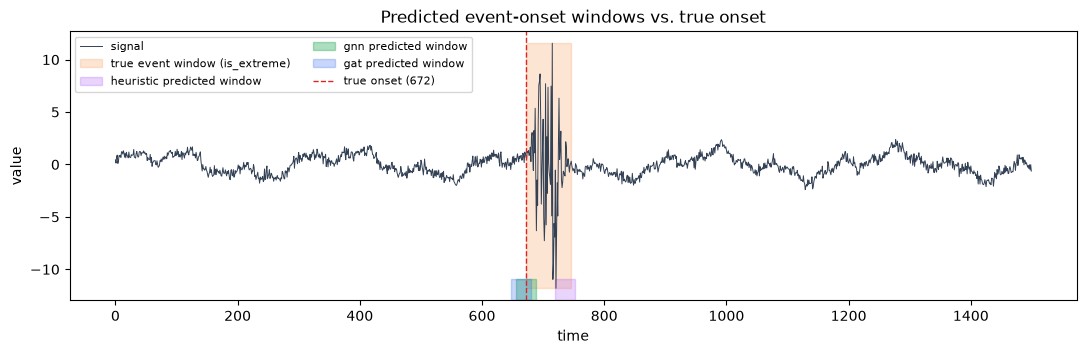

In [7]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df["timestamp"], x, color="#334155", linewidth=0.7, label="signal")
ax.fill_between(df["timestamp"], x.min(), x.max(), where=event_mask, color="#f97316", alpha=0.18,
                label="true event window (is_extreme)")
colors = {"heuristic": "#a855f7", "gnn": "#16a34a", "gat": "#2563eb"}
offsets = {"heuristic": -0.9, "gnn": -0.6, "gat": -0.3}
for method, node in predictions.items():
    start, stop = node_to_window(node)
    ax.axvspan(start, stop, color=colors[method], alpha=0.25 if method != "gnn" else 0.35,
               ymin=0.0, ymax=0.08, label=f"{method} predicted window")
ax.axvline(true_onset, color="#dc2626", linestyle="--", linewidth=1, label=f"true onset ({true_onset})")
ax.set(title="Predicted event-onset windows vs. true onset", xlabel="time", ylabel="value")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.show()

GNN и GAT предсказывают окно, содержащее истинный onset; ранжированная выше (раздел 3) эвристика — нет. Это согласуется с валидационными метриками, а не противоречит им: `heuristic top1 ≈ 0`, у GNN/GAT — заметно выше.

## 5. Согласование baseline-масштабирования

Остальные `1-d`-ноутбуки (`03`–`08`) используют **oracle-assisted** `EVTConfig.baseline_size = event_start` — известный момент onset конкретной записи, потому что там всегда ровно одна запись за раз. Здесь `TemporalGraphConfig.baseline_size` — **одно** число, общее для 24 разных обучающих записей с разными onset (диапазон выведен в разделе 2), поэтому oracle-значение недоступно по конструкции: нужен единый безопасный запас. `generate_additive_fractal_series` (как и `generate_fractal_extreme_series`) никогда не ставит onset раньше `n_points // 4`; при `n_points=1500` это `375`, так что `baseline_size=300` — заведомо безопасный отступ, а не подобранное на глаз число (см. `assert` в разделе 2). Тот же принцип уже использовался в `n-d/09` для общего `baseline_size` обучающих записей — совпадение неслучайно: это одна и та же проблема ("общий baseline для многих записей"), возникающая всякий раз, когда `ProcessModelTrainer` обучается на пакете независимых записей, а не запускается заново на одной.

**Самопроверка:** что произойдёт с `assert` в разделе 2, если добавить запись с `n_points=1000`? Почему нельзя просто взять `baseline_size = min(onset) - 1` по уже сгенерированным записям? Как изменится карта окон (раздел 1), если `stride` станет больше `window_size`?

## 6. Сохранение модели

`GraphProcessModel.save`/`.load` — та же npz-based (без pickle) persistence-логика, что доступна и для канальных моделей `n-d`; она не знает и не должна знать, что граф был временным, а не канальным — сохраняются только веса, стандартизация и конфигурация.

In [8]:
artifact_dir = ROOT / "results/1-d"
artifact_dir.mkdir(parents=True, exist_ok=True)
model_path = artifact_dir / "09_temporal_gnn_gat_model.npz"
training_report.model.save(model_path)

reloaded_model = GraphProcessModel.load(model_path)
reloaded_prediction = reloaded_model.predict(real_features, real_adjacency)
matches = (
    np.allclose(reloaded_prediction.gnn_probabilities, real_prediction.gnn_probabilities)
    and np.allclose(reloaded_prediction.gat_probabilities, real_prediction.gat_probabilities)
)
{"saved_to": str(model_path.relative_to(ROOT)), "size_bytes": model_path.stat().st_size,
 "reload_matches_original_prediction": matches}

{'saved_to': 'results/1-d/09_temporal_gnn_gat_model.npz',
 'size_bytes': 5314,
 'reload_matches_original_prediction': True}

## Интерпретация

Временной граф превращает одномерную задачу локализации в ту же форму, что и канальная: узлы, рёбра, пять признаков, `GraphEpisode`, `ProcessModelTrainer.train`. Это позволило переиспользовать без изменений разбиение по группам, метрики ранжирования и persistence — не переписывая их для 1-D. Единственное действительно новое место — интерпретация результата: узел графа не физический источник, а окно времени, и это отображение (`window_starts[node] → [start, start + window_size)`) нужно делать явно на стороне вызывающего кода.

Готовая эвристика, перенесённая из канального контекста, здесь ненадёжна: одинаковые имена признаков не гарантируют одинаковый смысл. Обученная модель обошла это на реальном ряде, но раздел 3 показывает это как измеренный, а не предполагаемый факт — и как в `n-d/09`, единственная удачная проверка на одном ряде не образует benchmark.